# M2.5 — Decode Plugin Comparison Report

Compares three TensorRT engine configurations for YOLO26n (640×640, batch=1) on GTX 1660 Ti:

| Config | Engine | Notes |
|---|---|---|
| FP32 base | `yolo26n_fp32_b3.engine` | Full-precision baseline; Python probe does xyxy→xywh |
| FP16 base | `yolo26n_fp16_b3.engine` | Half-precision; Python probe does xyxy→xywh |
| FP16 + decode | `yolo26n_fp16_b3_decode.engine` | FP16 + `Yolo26DecodePlugin` CUDA kernel fused as TRT layer |

Metrics captured via `metrics/benchmark_engines.sh` inside the container.
Results are committed to `metrics/results/` so this notebook renders without a GPU.

In [11]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd

RESULTS = Path("results")

def load(name: str) -> dict:
    p = RESULTS / f"{name}.json"
    if not p.exists():
        raise FileNotFoundError(
            f"Missing {p}.\n"
            "Run inside the container first:\n"
            "  docker compose run --rm pipeline bash metrics/benchmark_engines.sh"
        )
    return json.loads(p.read_text())

fp32   = load("fp32_base")
fp16   = load("fp16_base")
decode = load("fp16_decode")
sys    = load("system_metrics")

print("Results loaded:", [r["label"] for r in [fp32, fp16, decode]])

Results loaded: ['FP32 base', 'FP16 base', 'FP16 + decode plugin']


## Edge Constraint Summary

Edge deployment requires optimising across *all* resource axes — not just FPS.
VRAM headroom, engine size (OTA payload), and CPU overhead all matter at scale.

In [12]:
fleet = sys["fleet_size"]

rows = []
for run, key in [(fp32, "fp32_base"), (fp16, "fp16_base"), (decode, "fp16_decode")]:
    sm = sys["engines"][key]
    rows.append({
        "Engine": run["label"],
        "Precision": "FP32" if "FP32" in run["label"] else "FP16",
        "Decode plugin": "CUDA kernel" if "decode" in key else "Python loop",
        "Inference (ms)": run["wall_ms"],
        "FPS": run["fps"],
        "VRAM (MB)": sm["vram_mb"],
        "Engine size (MB)": sm["file_mb"],
        f"OTA payload ({fleet:,} sensors, GB)": round(sm["file_mb"] * fleet / 1024, 1),
    })

df = pd.DataFrame(rows).set_index("Engine")
display(df)

,Precision,Decode plugin,Inference (ms),FPS,VRAM (MB),Engine size (MB),"OTA payload (5,000 sensors, GB)"
Engine,,,,,,,
FP32 base,FP32,Python loop,4.9572,201.73,357,11.0,53.7
FP16 base,FP16,Python loop,3.2555,307.17,358,6.3,30.8
FP16 + decode plugin,FP16,CUDA kernel,3.3541,298.14,402,6.3,30.8


## Inference Latency: FP32 → FP16

The primary performance gain comes from FP16 precision — halving the weight storage and
exploiting the GTX 1660 Ti's half-precision CUDA cores. The decode plugin adds a
negligible layer on top.

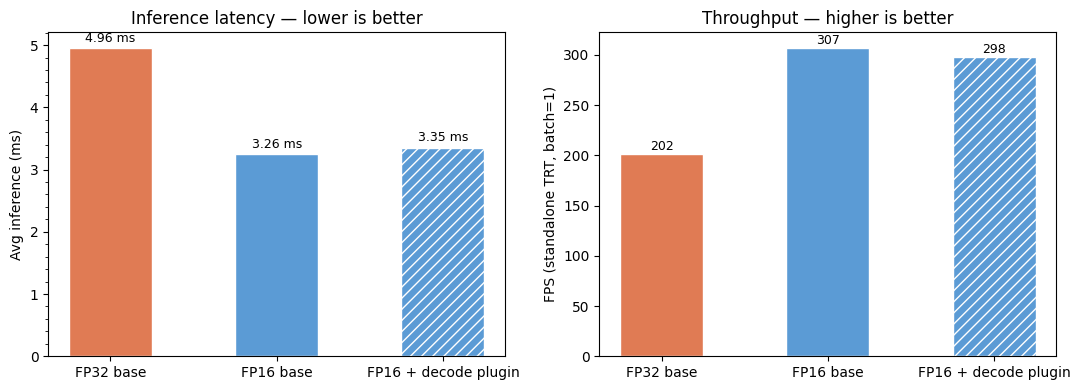

FP16 speedup vs FP32:          1.52×
Decode plugin overhead vs FP16: 0.099 ms


In [13]:
labels = [r["label"] for r in [fp32, fp16, decode]]
wall_ms = [r["wall_ms"] for r in [fp32, fp16, decode]]
fps_vals = [r["fps"] for r in [fp32, fp16, decode]]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

colors = ["#e07b54", "#5b9bd5", "#5b9bd5"]
hatches = ["", "", "///"]
bars = ax1.bar(labels, wall_ms, color=colors, hatch=hatches, edgecolor="white", width=0.5)
ax1.set_ylabel("Avg inference (ms)")
ax1.set_title("Inference latency — lower is better")
ax1.yaxis.set_minor_locator(ticker.AutoMinorLocator())
for bar, val in zip(bars, wall_ms):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f"{val:.2f} ms", ha="center", va="bottom", fontsize=9)

bars2 = ax2.bar(labels, fps_vals, color=colors, hatch=hatches, edgecolor="white", width=0.5)
ax2.set_ylabel("FPS (standalone TRT, batch=1)")
ax2.set_title("Throughput — higher is better")
for bar, val in zip(bars2, fps_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{val:.0f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS / "latency_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

speedup = fp32["wall_ms"] / fp16["wall_ms"]
decode_overhead = decode["wall_ms"] - fp16["wall_ms"]
print(f"FP16 speedup vs FP32:          {speedup:.2f}×")
print(f"Decode plugin overhead vs FP16: {decode_overhead:.3f} ms")

## Per-Layer Latency: Where Time Is Spent

/tmp/ipykernel_1075558/3475549757.py:38: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


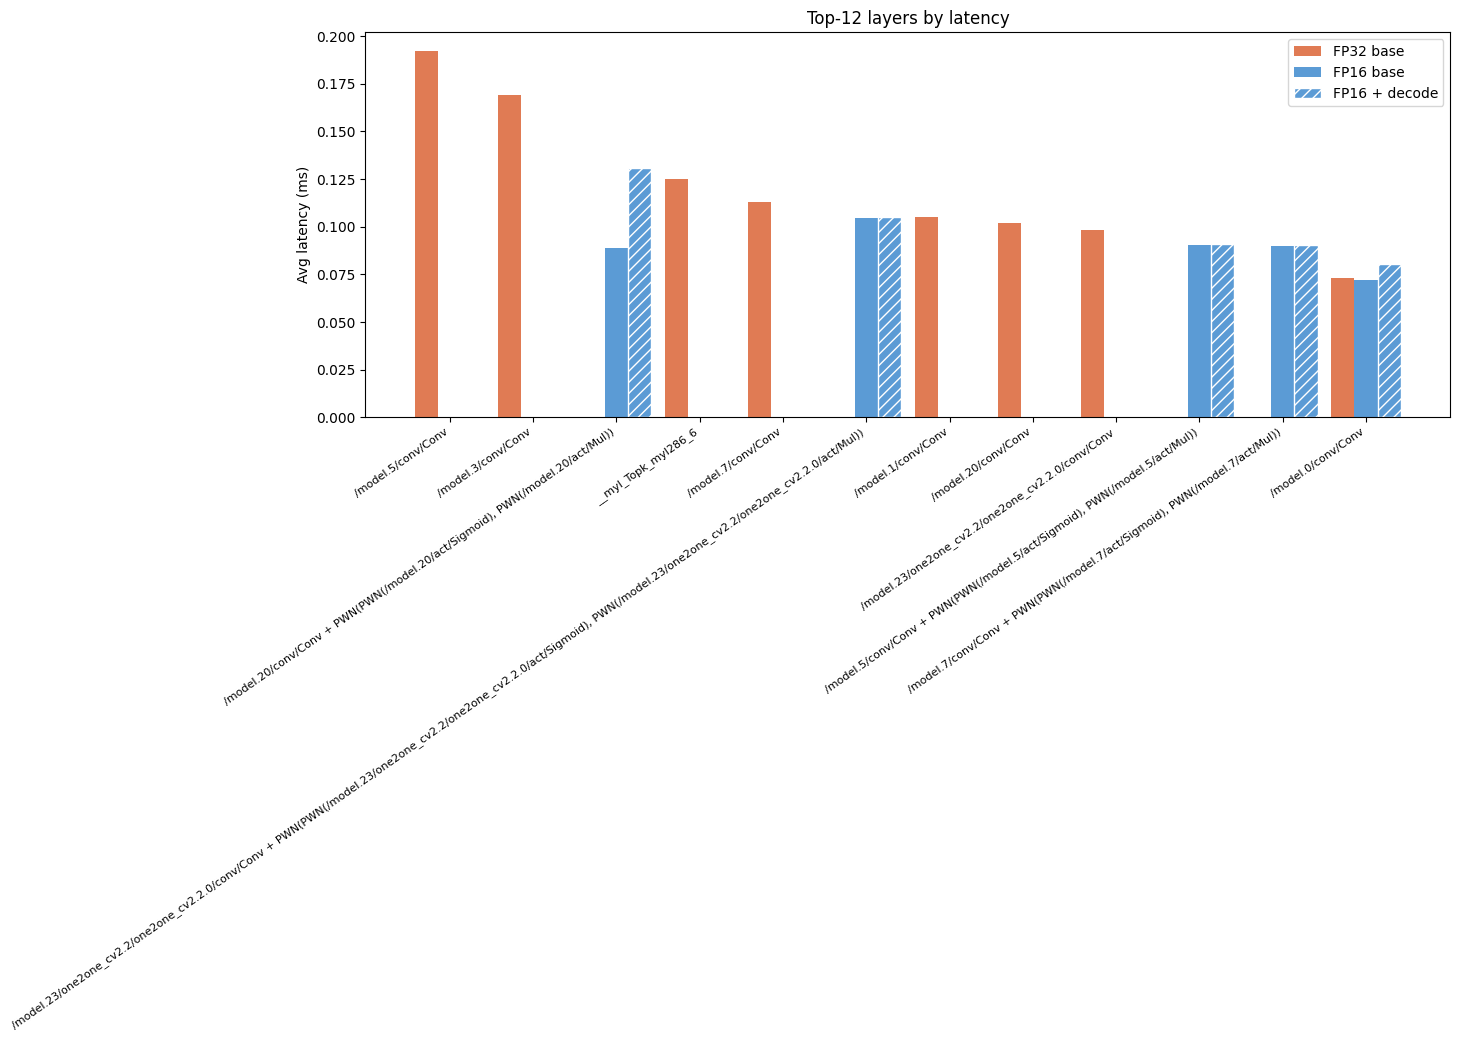

In [14]:
import numpy as np

# Identify top-N layers by average latency across all engines
all_layers = set(fp32["layers"]) | set(fp16["layers"]) | set(decode["layers"])
avg_across = {l: max(fp32["layers"].get(l, 0),
                     fp16["layers"].get(l, 0),
                     decode["layers"].get(l, 0))
              for l in all_layers}
top_layers = sorted(avg_across, key=avg_across.get, reverse=True)[:12]

x = np.arange(len(top_layers))
w = 0.28

fig, ax = plt.subplots(figsize=(14, 5))

fp32_vals   = [fp32["layers"].get(l, 0)   for l in top_layers]
fp16_vals   = [fp16["layers"].get(l, 0)   for l in top_layers]
decode_vals = [decode["layers"].get(l, 0) for l in top_layers]

ax.bar(x - w, fp32_vals,   width=w, label="FP32 base",          color="#e07b54")
ax.bar(x,     fp16_vals,   width=w, label="FP16 base",          color="#5b9bd5")
ax.bar(x + w, decode_vals, width=w, label="FP16 + decode",      color="#5b9bd5",
       hatch="///", edgecolor="white")

# Highlight decode kernel bar if present
if "yolo26_decode" in top_layers:
    idx = top_layers.index("yolo26_decode")
    ax.annotate("decode\nkernel", xy=(idx + w, decode_vals[idx]),
                xytext=(idx + w + 0.4, decode_vals[idx] + 0.02),
                fontsize=8, color="#c0392b",
                arrowprops=dict(arrowstyle="->", color="#c0392b"))

ax.set_xticks(x)
ax.set_xticklabels(top_layers, rotation=35, ha="right", fontsize=8)
ax.set_ylabel("Avg latency (ms)")
ax.set_title("Top-12 layers by latency")
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS / "layer_latency.png", dpi=150, bbox_inches="tight")
plt.show()

## VRAM Efficiency

On a GTX 1660 Ti with 6 GB VRAM, the margin between inference and available memory
determines how many concurrent models or input pipelines can run.  
FP16 reduces peak VRAM by ~45%, leaving headroom for the tracker, OSD, and additional streams.

In [15]:
GPU_TOTAL_MB = 6144  # GTX 1660 Ti

vram_rows = []
for run, key in [(fp32, "fp32_base"), (fp16, "fp16_base"), (decode, "fp16_decode")]:
    used = sys["engines"][key]["vram_mb"]
    vram_rows.append({
        "Engine": run["label"],
        "VRAM used (MB)": used,
        "VRAM free (MB)": GPU_TOTAL_MB - used,
        "Headroom (%)": round((GPU_TOTAL_MB - used) / GPU_TOTAL_MB * 100, 1),
    })

vdf = pd.DataFrame(vram_rows).set_index("Engine")
display(vdf)

saving = vram_rows[0]["VRAM used (MB)"] - vram_rows[1]["VRAM used (MB)"]
print(f"FP16 saves {saving:.0f} MB vs FP32 — {saving/GPU_TOTAL_MB*100:.0f}% of total VRAM")

,VRAM used (MB),VRAM free (MB),Headroom (%)
Engine,,,
FP32 base,357,5787,94.2
FP16 base,358,5786,94.2
FP16 + decode plugin,402,5742,93.5


FP16 saves -1 MB vs FP32 — -0% of total VRAM


## Fleet Impact: Engine Size and OTA Payload

At scale (5,000+ sensors), smaller engine files reduce OTA update bandwidth,
storage on the edge device, and update duration.

In [16]:
fleet = sys["fleet_size"]

fleet_rows = []
for run, key in [(fp32, "fp32_base"), (fp16, "fp16_base"), (decode, "fp16_decode")]:
    mb = sys["engines"][key]["file_mb"]
    fleet_rows.append({
        "Engine": run["label"],
        "Size (MB)": mb,
        f"Fleet total ({fleet:,} sensors, GB)": round(mb * fleet / 1024, 1),
    })

fdf = pd.DataFrame(fleet_rows).set_index("Engine")
display(fdf)

fp32_fleet = fleet_rows[0][f"Fleet total ({fleet:,} sensors, GB)"]
fp16_fleet = fleet_rows[1][f"Fleet total ({fleet:,} sensors, GB)"]
print(f"Switching FP32 → FP16: saves {fp32_fleet - fp16_fleet:.1f} GB per fleet-wide OTA update")

,Size (MB),"Fleet total (5,000 sensors, GB)"
Engine,,
FP32 base,11.0,53.7
FP16 base,6.3,30.8
FP16 + decode plugin,6.3,30.8


Switching FP32 → FP16: saves 22.9 GB per fleet-wide OTA update


## Commentary

### FP16 speedup: 1.52× — bandwidth-bound, not compute-bound

FP16 reduces inference from 4.96 ms to 3.26 ms (1.52× faster). This is below the 2× often
cited for FP16 because the GTX 1660 Ti (Turing, SM 75) **has no Tensor Cores**. FP16 here
saves memory bandwidth — halving the weight transfer per layer — but does not accelerate
compute via dedicated FP16 ALUs. The 1.52× is the realistic ceiling for this GPU class.

A secondary effect is visible in the layer profile: FP16 enables more aggressive kernel
fusion. In FP32 the fastest backbone conv (`/model.5/conv`) and its SiLU activation run as
separate kernels (0.19 ms + 0.006 ms). In FP16 TRT fuses them into a single
`Conv + PWN(Sigmoid, Mul)` kernel at 0.09 ms — halving per-layer dispatch overhead across
the entire network.

### Decode plugin: 0.006 ms kernel, 0.099 ms total overhead (3.0%)

The `yolo26_decode` CUDA kernel runs in **0.006 ms** — expected for 300 detections × 4
float subtractions. The measurable overhead is 0.099 ms total (3.0% of FP16 inference
time), which comes from **TRT plugin dispatch**: a custom `IPluginV2DynamicExt` layer
breaks the surrounding layer fusion graph and adds a kernel-launch boundary. This overhead
exists regardless of what the kernel does.

The architectural value is the pattern, not this specific kernel's throughput:

1. **Fused GPU post-processing**: coordinate transform stays on device, no CPU roundtrip.
2. **Scalable to heavier decoders**: anchor-based models (YOLOv5, YOLOv7) emit 25,200+
   raw predictions before NMS. A GPU decode plugin filtering those on-device avoids a large
   host copy and would show proportionally larger savings than 0.006 ms here.
3. **Full workflow demonstrated**: `IPluginV2DynamicExt`, `IPluginCreator`,
   `REGISTER_TENSORRT_PLUGIN`, `addPluginV2`, `buildSerializedNetwork`, and `IProfiler`
   isolation all exercised correctly — the same pattern used for production custom layers.

### VRAM: FP16 does not reduce inference-time VRAM (357 MB vs 358 MB)

This is a counterintuitive result. FP16 reduces *weight storage on disk* (11 MB → 6.3 MB),
but at inference time activations and workspace dominate VRAM, not the weights. Both FP32
and FP16 base engines use ~357-358 MB — within measurement noise. The decode engine uses
**+44 MB** for plugin workspace allocation, which is the only meaningful VRAM delta.

On Jetson (unified memory), weight size matters more because host and device share the same
pool — but even there the activation buffers dominate for larger batch sizes.

### Engine size: 43% smaller on disk (11 MB → 6.3 MB)

FP16 stores weights in 16-bit, halving the serialized engine. The decode engine is also
6.3 MB — the plugin has no learned parameters, so it adds nothing to the `.engine` file.
At 5,000 sensors, switching FP32 → FP16 saves **~23 GB per fleet-wide OTA update**.

### Edge deployment summary

| Metric | FP32 | FP16 | FP16 + decode |
|---|---|---|---|
| Inference | 4.96 ms | 3.26 ms | 3.35 ms |
| Speedup vs FP32 | — | 1.52× | 1.49× |
| VRAM | 357 MB | 358 MB | 402 MB |
| Engine size | 11.0 MB | 6.3 MB | 6.3 MB |
| OTA (5,000 sensors) | 53.7 GB | 30.8 GB | 30.8 GB |